# Entrenamiento de modelos de clasificación multiclase sin ingeniería de características

In [1]:
## Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

## Carga y separación

### Carga de los conjuntos de entrenamiento y prueba

In [2]:
train_df = pd.read_csv("data/processed/train.csv")
test_df = pd.read_csv("data/processed/test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (10888, 17)
Test shape: (2723, 17)


### Separación de variables predictoras y variable objetivo

In [3]:
X_train = train_df.drop(columns=["Class"])
y_train = train_df["Class"]

X_test = test_df.drop(columns=["Class"])
y_test = test_df["Class"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10888, 16)
X_test: (2723, 16)
y_train: (10888,)
y_test: (2723,)


## Modelo Perceptrón

### Entrenamiento del modelo Perceptrón

In [4]:
perceptron_model = Perceptron(random_state=7833)

perceptron_model.fit(X_train, y_train)

y_pred_perceptron = perceptron_model.predict(X_test)

perceptron_model

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",7833


### Evaluación del modelo Perceptrón

In [5]:
accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
f1_perceptron = f1_score(y_test, y_pred_perceptron, average="macro")

print("Accuracy:", accuracy_perceptron)
print("F1 Macro:", f1_perceptron)

Accuracy: 0.21226588321704004
F1 Macro: 0.09869265524335101


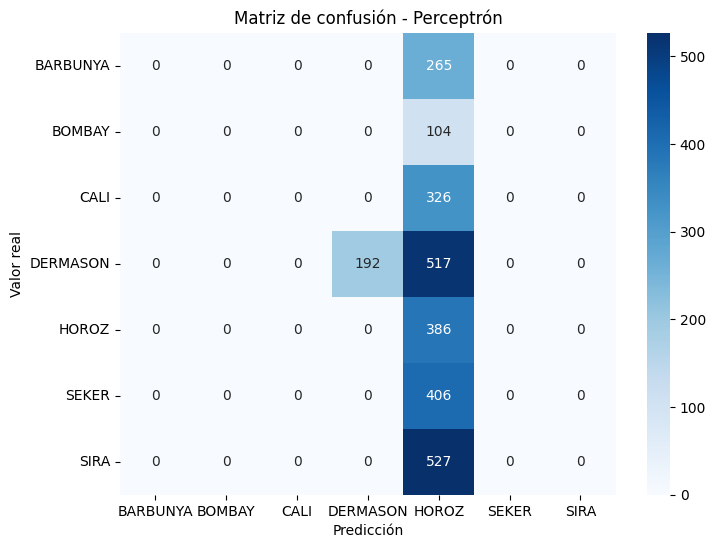

In [6]:
cm_perceptron = confusion_matrix(y_test, y_pred_perceptron, labels=perceptron_model.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_perceptron,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=perceptron_model.classes_,
    yticklabels=perceptron_model.classes_
)
plt.title("Matriz de confusión - Perceptrón")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [7]:
print(classification_report(y_test, y_pred_perceptron))

              precision    recall  f1-score   support

    BARBUNYA       0.00      0.00      0.00       265
      BOMBAY       0.00      0.00      0.00       104
        CALI       0.00      0.00      0.00       326
    DERMASON       1.00      0.27      0.43       709
       HOROZ       0.15      1.00      0.26       386
       SEKER       0.00      0.00      0.00       406
        SIRA       0.00      0.00      0.00       527

    accuracy                           0.21      2723
   macro avg       0.16      0.18      0.10      2723
weighted avg       0.28      0.21      0.15      2723



/Users/victor.borrayo/Desktop/Prueba/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/victor.borrayo/Desktop/Prueba/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/victor.borrayo/Desktop/Prueba/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

## Modelo Regresión Logística

### Entrenamiento del modelo de Regresión Logística

In [8]:
logreg_model = LogisticRegression(max_iter=10000, random_state=7833)

logreg_model.fit(X_train, y_train)

y_pred_logreg = logreg_model.predict(X_test)

logreg_model

/Users/victor.borrayo/Desktop/Prueba/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",7833
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Evaluación del modelo de Regresión Logística

In [9]:
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg, average="macro")

print("Accuracy:", accuracy_logreg)
print("F1 Macro:", f1_logreg)

Accuracy: 0.9184722732280572
F1 Macro: 0.9283744024632118


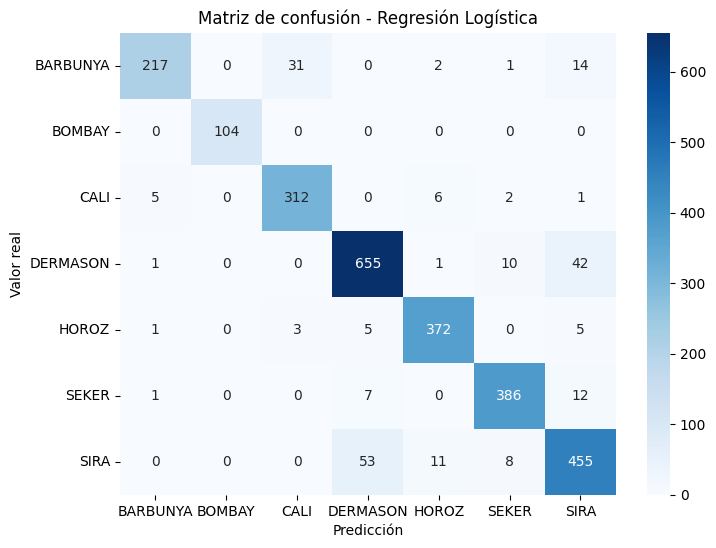

In [10]:
cm_logreg = confusion_matrix(y_test, y_pred_logreg, labels=logreg_model.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_logreg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=logreg_model.classes_,
    yticklabels=logreg_model.classes_
)
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [11]:
print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

    BARBUNYA       0.96      0.82      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.96      0.93       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.95      0.96      0.96       386
       SEKER       0.95      0.95      0.95       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



## Modelo Árbol de Decisión

**Estudiante:**

Debe completar el entrenamiento de este modelo así como la evaluación.

Para compatibilidad en la comparación de resultados. Debe utilizar estos nombres para las métricas: accuracy_tree y f1_tree.

Nota: Recuerde utilizar el random_state que se ha utilizado en los otros modelos para conseguir coincidencias exactas en la evaluación.

### Entrenamiento del modelo Árbol de Decisión

In [12]:
tree_model = DecisionTreeClassifier(random_state=7833)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

tree_model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",7833
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### Evaluación del modelo Árbol de Decisión

In [13]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree, average="macro")

print("Accuracy:", accuracy_tree)
print("F1 Macro:", f1_tree)

Accuracy: 0.8979067205288285
F1 Macro: 0.9121093736828537


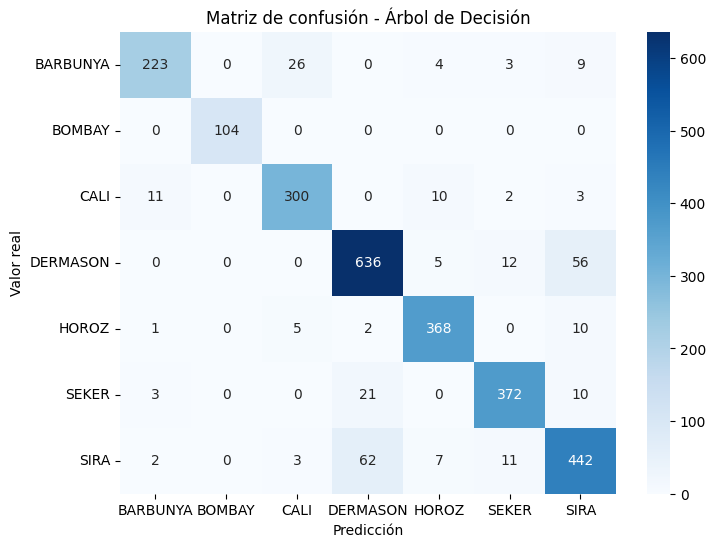

In [14]:
cm_tree = confusion_matrix(y_test, y_pred_tree, labels=tree_model.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=tree_model.classes_,
    yticklabels=tree_model.classes_
)
plt.title("Matriz de confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [15]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.84      0.88       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.92      0.91       326
    DERMASON       0.88      0.90      0.89       709
       HOROZ       0.93      0.95      0.94       386
       SEKER       0.93      0.92      0.92       406
        SIRA       0.83      0.84      0.84       527

    accuracy                           0.90      2723
   macro avg       0.92      0.91      0.91      2723
weighted avg       0.90      0.90      0.90      2723



## Comparación de métricas de los tres modelos

In [16]:
results_df = pd.DataFrame({
    "Modelo": ["Perceptrón", "Regresión Logística", "Árbol de Decisión"],
    "Accuracy": [accuracy_perceptron, accuracy_logreg, accuracy_tree],
    "F1 Macro": [f1_perceptron, f1_logreg, f1_tree]
})

results_df

,Modelo,Accuracy,F1 Macro
0,Perceptrón,0.212266,0.098693
1,Regresión Logística,0.918472,0.928374
2,Árbol de Decisión,0.897907,0.912109


## Visualización comparativa de métricas

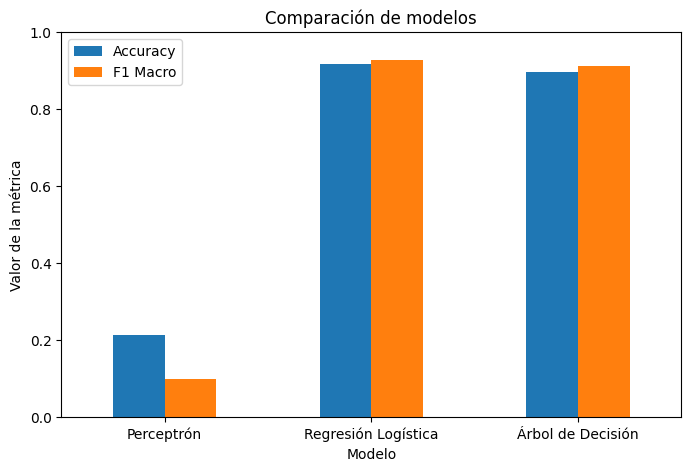

In [17]:
results_plot = results_df.set_index("Modelo")

results_plot.plot(kind="bar", figsize=(8,5))
plt.title("Comparación de modelos")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

## Conclusión

In [18]:
best_accuracy_model = results_df.loc[results_df["Accuracy"].idxmax(), "Modelo"]
best_f1_model = results_df.loc[results_df["F1 Macro"].idxmax(), "Modelo"]

print("Modelo con mejor Accuracy:", best_accuracy_model)
print("Modelo con mejor F1 Macro:", best_f1_model)

Modelo con mejor Accuracy: Regresión Logística
Modelo con mejor F1 Macro: Regresión Logística
